# 3. Visualise ASHD and AEDP 148-Household PyNNLF Results

This notebook visualises the processed ASHD 148-household weather results across 30-minute, 1-day, and 1-week horizons, then compares ASHD and AEDP at the shared 1-day horizon.

Run this after `2_process_pynnlf_output_ashd_aedp_148hh.ipynb`.

## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def find_publication_project(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "specs" / "ashd_148hh_batch.yaml").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Could not find publication/journal_article_1 from the current working directory.")


PROJECT_DIR = find_publication_project(Path.cwd().resolve())
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures" / "03_ashd_148hh_run"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = [
    "m1_naive_hp1",
    "m2_snaive_hp2",
    "m3_ets_hp1",
    "m4_arima_hp1",
    "m6_lr_hp1",
    "m7_ann_hp1",
    "m8_dnn_hp1",
    "m9_rt_hp3",
    "m10_rf_hp1",
    "m13_lstm_hp2",
    "m16_prophet_hp1",
    "m17_xgb_hp1",
]
HORIZON_LABELS = {
    "30_min": "30 minutes",
    "1_day": "1 day",
    "1_week": "1 week",
}
DATASET_LABELS = {
    "ASHD_148hh_weather": "ASHD 148 households",
    "AEDP_148hh_weather": "AEDP 148 households",
}
COLORS = {
    "30_min": "#2f5597",
    "1_day": "#70ad47",
    "1_week": "#c55a11",
    "ASHD_148hh_weather": "#2F4D67",
    "AEDP_148hh_weather": "#EB932C",
}
BEST_BAR_HATCH = "///"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


print(f"Publication project: {PROJECT_DIR}")
print(f"Figures directory: {FIGURES_DIR}")


Publication project: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1
Figures directory: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run


## 2. Load processed result tables

In [2]:
required_files = {
    "ashd_nrmse": RESULTS_DIR / "ashd_148hh_weather_nrmse_by_horizon.csv",
    "ashd_stddev": RESULTS_DIR / "ashd_148hh_weather_nrmse_stddev_by_horizon.csv",
    "comparison_nrmse": RESULTS_DIR / "ashd_aedp_148hh_fh8_nrmse_comparison.csv",
    "comparison_stddev": RESULTS_DIR / "ashd_aedp_148hh_fh8_nrmse_stddev_comparison.csv",
    "combined": RESULTS_DIR / "ashd_aedp_148hh_combined_recap.csv",
}
missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing processed result files. Run 2_process_pynnlf_output_ashd_aedp_148hh.ipynb first. "
        f"Missing: {missing}"
    )

ashd_nrmse = pd.read_csv(required_files["ashd_nrmse"], index_col=0).reindex(MODEL_ORDER)
ashd_stddev = pd.read_csv(required_files["ashd_stddev"], index_col=0).reindex(MODEL_ORDER)
comparison_nrmse = pd.read_csv(required_files["comparison_nrmse"], index_col=0).reindex(MODEL_ORDER)
comparison_stddev = pd.read_csv(required_files["comparison_stddev"], index_col=0).reindex(MODEL_ORDER)
combined = pd.read_csv(required_files["combined"])

display(ashd_nrmse.round(3))
display(comparison_nrmse.round(3))


,30_min,1_day,1_week
model_hp,,,
m1_naive_hp1,4.225,9.091,10.937
m2_snaive_hp2,10.946,10.953,10.937
m3_ets_hp1,4.147,9.142,10.981
m4_arima_hp1,3.557,16.179,17.847
m6_lr_hp1,2.657,7.763,8.757
m7_ann_hp1,6.531,8.150,8.836
m8_dnn_hp1,4.138,7.690,8.578
m9_rt_hp3,7.451,10.122,10.445
m10_rf_hp1,4.967,8.490,8.995


,ASHD_148hh_weather,AEDP_148hh_weather
model_hp,,
m1_naive_hp1,9.091,24.298
m2_snaive_hp2,10.953,30.027
m3_ets_hp1,9.142,24.184
m4_arima_hp1,16.179,37.021
m6_lr_hp1,7.763,20.951
m7_ann_hp1,8.150,20.380
m8_dnn_hp1,7.690,20.408
m9_rt_hp3,10.122,26.321
m10_rf_hp1,8.490,21.893


## 3. ASHD performance across forecast horizons

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig01_ashd_nrmse_by_horizon.png


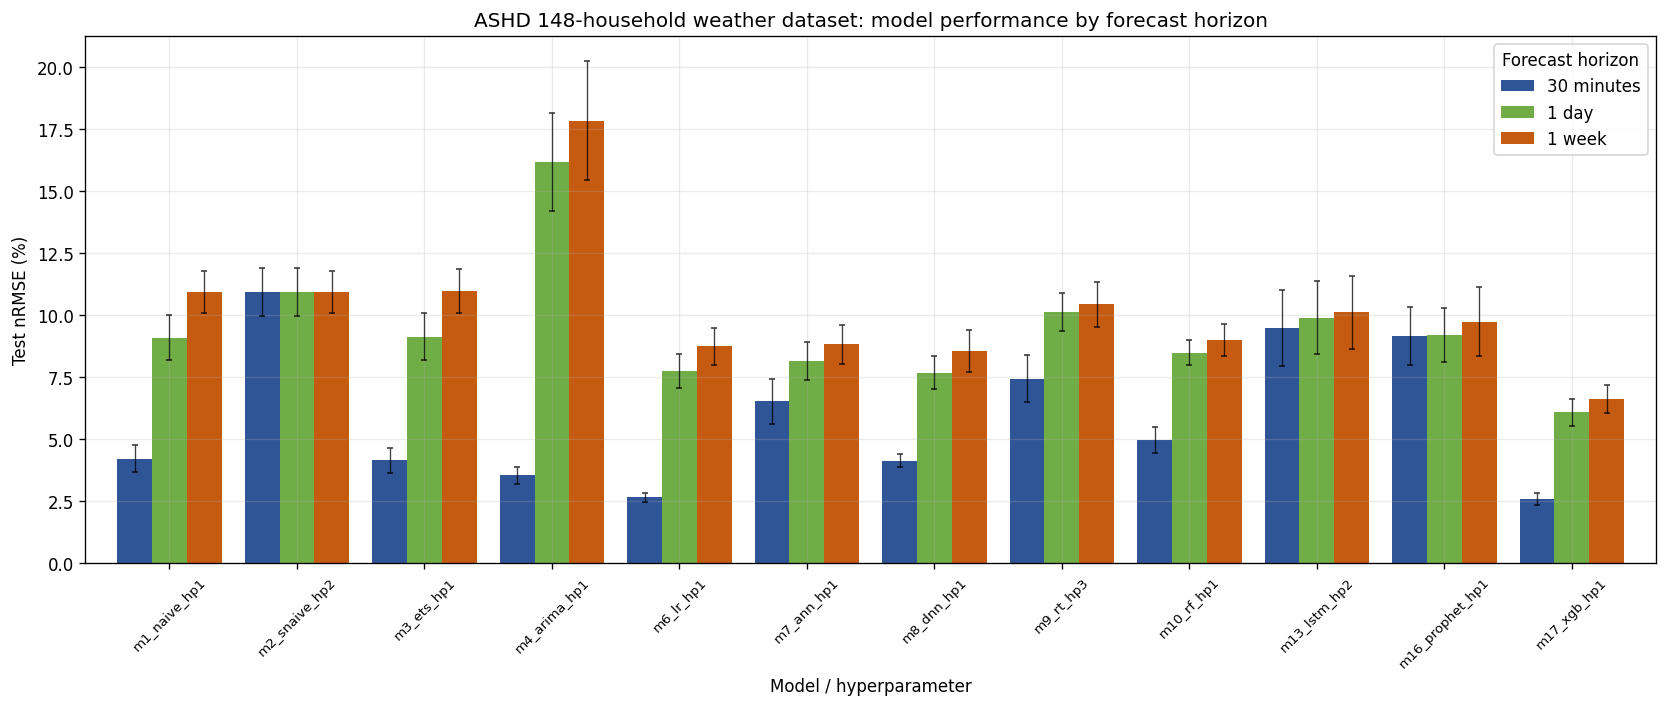

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig02_ashd_nrmse_stddev_by_horizon.png


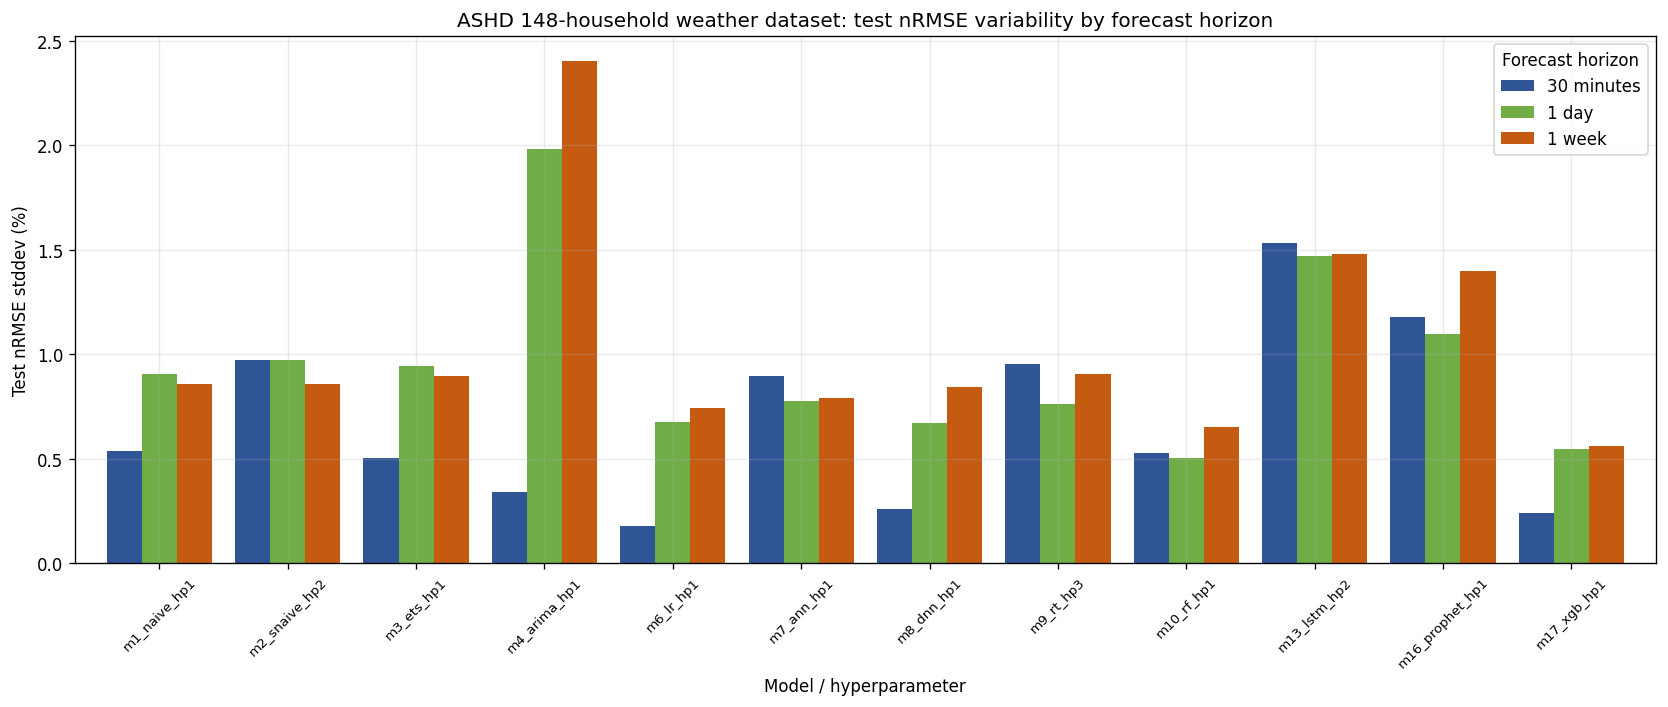

In [3]:
plot_nrmse = ashd_nrmse.rename(columns=HORIZON_LABELS)
plot_stddev = ashd_stddev.rename(columns=HORIZON_LABELS)

fig, ax = plt.subplots(figsize=(14, 6))
plot_nrmse.plot(
    kind="bar",
    yerr=plot_stddev,
    ax=ax,
    width=0.82,
    capsize=2,
    color=[COLORS[column] for column in ashd_nrmse.columns],
    error_kw={"elinewidth": 0.8, "alpha": 0.75},
)
ax.set_ylabel("Test nRMSE (%)")
ax.set_xlabel("Model / hyperparameter")
ax.set_title("ASHD 148-household weather dataset: model performance by forecast horizon")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(title="Forecast horizon")
fig.tight_layout()
save_figure(fig, "fig01_ashd_nrmse_by_horizon.png")
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
plot_stddev.plot(
    kind="bar",
    ax=ax,
    width=0.82,
    color=[COLORS[column] for column in ashd_stddev.columns],
)
ax.set_ylabel("Test nRMSE stddev (%)")
ax.set_xlabel("Model / hyperparameter")
ax.set_title("ASHD 148-household weather dataset: test nRMSE variability by forecast horizon")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(title="Forecast horizon")
fig.tight_layout()
save_figure(fig, "fig02_ashd_nrmse_stddev_by_horizon.png")
plt.show()


## 4. Best ASHD model by horizon

,horizon,best_model_hp,test_nRMSE,test_nRMSE_stddev
0,30 minutes,m17_xgb_hp1,2.612,0.243
1,1 day,m17_xgb_hp1,6.087,0.546
2,1 week,m17_xgb_hp1,6.611,0.560


Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig03_ashd_best_model_by_horizon.png


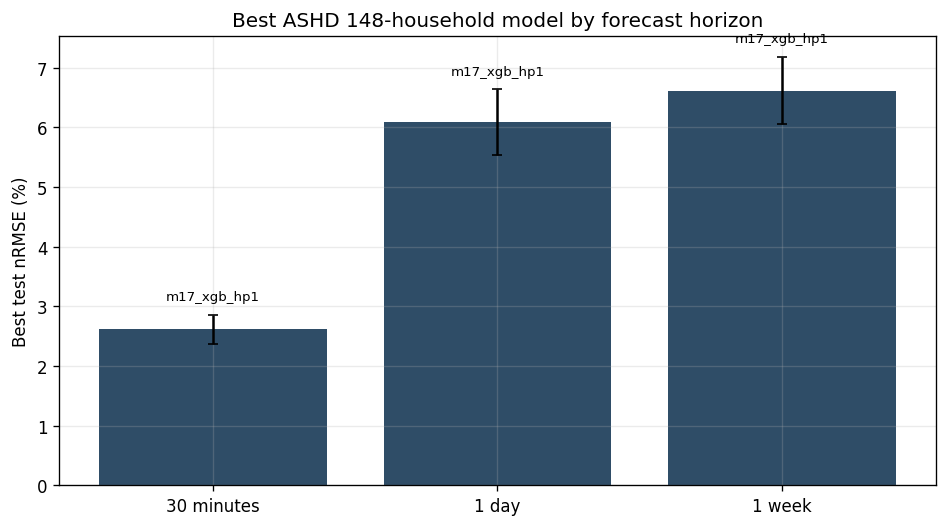

In [4]:
best_rows = []
for horizon in ashd_nrmse.columns:
    best_model = ashd_nrmse[horizon].idxmin()
    best_rows.append({
        "horizon": HORIZON_LABELS[horizon],
        "best_model_hp": best_model,
        "test_nRMSE": ashd_nrmse.loc[best_model, horizon],
        "test_nRMSE_stddev": ashd_stddev.loc[best_model, horizon],
    })
best_by_horizon = pd.DataFrame(best_rows)
display(best_by_horizon.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(best_by_horizon["horizon"], best_by_horizon["test_nRMSE"], color="#2F4D67", yerr=best_by_horizon["test_nRMSE_stddev"], capsize=3)
for index, row in best_by_horizon.iterrows():
    ax.text(index, row["test_nRMSE"] + row["test_nRMSE_stddev"] + 0.2, row["best_model_hp"], ha="center", va="bottom", fontsize=8, rotation=0)
ax.set_ylabel("Best test nRMSE (%)")
ax.set_title("Best ASHD 148-household model by forecast horizon")
fig.tight_layout()
save_figure(fig, "fig03_ashd_best_model_by_horizon.png")
plt.show()


## 5. ASHD vs AEDP at the shared 1-day horizon

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig04_ashd_aedp_fh8_nrmse_comparison.png


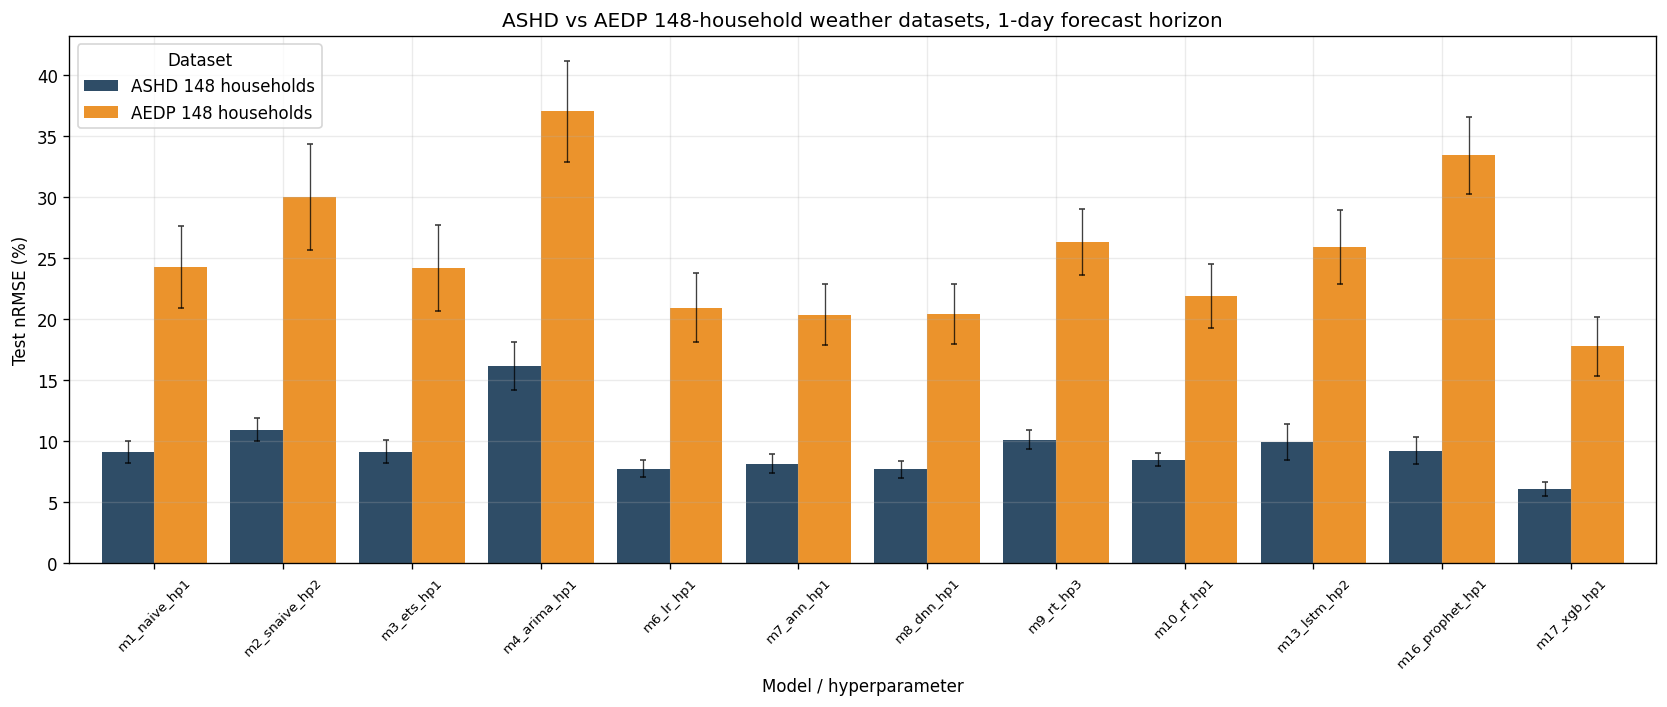

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig05_ashd_minus_aedp_fh8_nrmse_difference.png


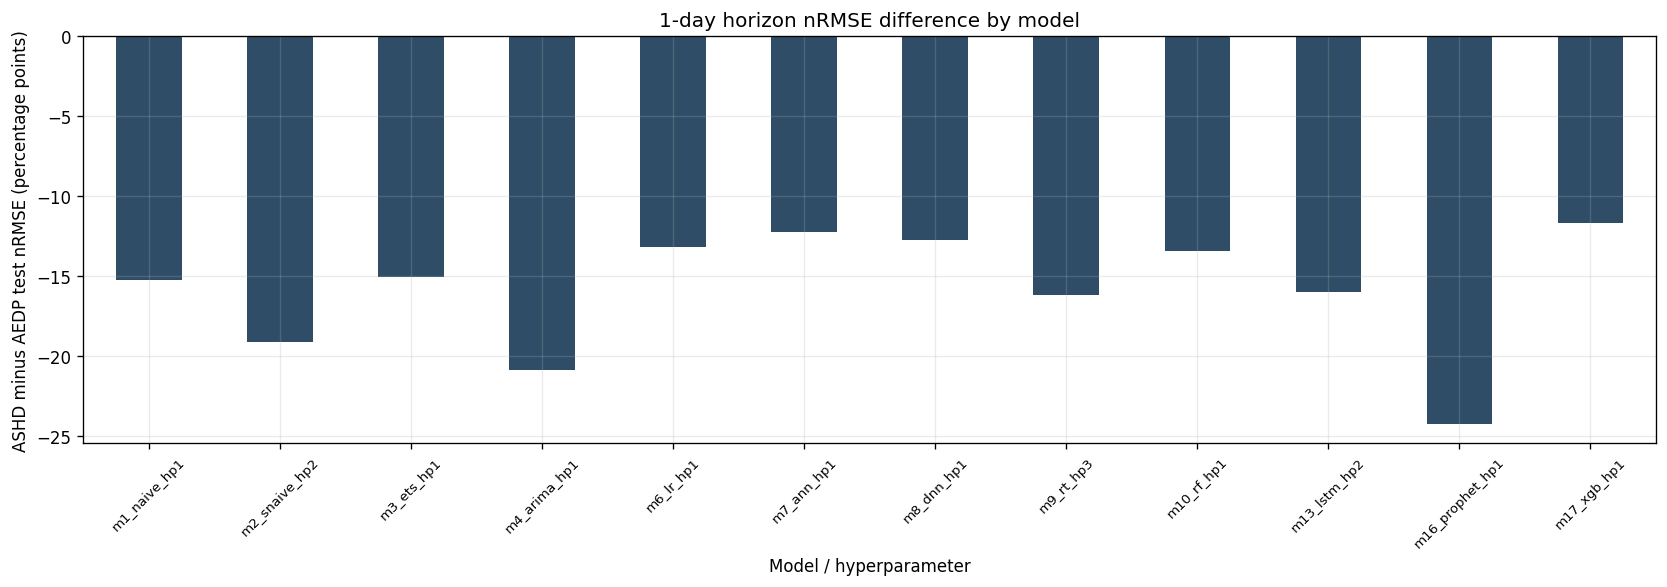

In [5]:
plot_comparison = comparison_nrmse.rename(columns=DATASET_LABELS)
plot_comparison_stddev = comparison_stddev.rename(columns=DATASET_LABELS)

fig, ax = plt.subplots(figsize=(14, 6))
plot_comparison.plot(
    kind="bar",
    yerr=plot_comparison_stddev,
    ax=ax,
    width=0.82,
    capsize=2,
    color=[COLORS[column] for column in comparison_nrmse.columns],
    error_kw={"elinewidth": 0.8, "alpha": 0.75},
)
ax.set_ylabel("Test nRMSE (%)")
ax.set_xlabel("Model / hyperparameter")
ax.set_title("ASHD vs AEDP 148-household weather datasets, 1-day forecast horizon")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(title="Dataset")
fig.tight_layout()
save_figure(fig, "fig04_ashd_aedp_fh8_nrmse_comparison.png")
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
difference = comparison_nrmse["ASHD_148hh_weather"] - comparison_nrmse["AEDP_148hh_weather"]
difference.plot(kind="bar", ax=ax, color=["#2F4D67" if value <= 0 else "#EB932C" for value in difference])
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("ASHD minus AEDP test nRMSE (percentage points)")
ax.set_xlabel("Model / hyperparameter")
ax.set_title("1-day horizon nRMSE difference by model")
ax.tick_params(axis="x", rotation=45, labelsize=8)
fig.tight_layout()
save_figure(fig, "fig05_ashd_minus_aedp_fh8_nrmse_difference.png")
plt.show()


## 6. Figure outputs

In [6]:
for path in sorted(FIGURES_DIR.glob("fig*.png")):
    print(path)


C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig01_ashd_nrmse_by_horizon.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig02_ashd_nrmse_stddev_by_horizon.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig03_ashd_best_model_by_horizon.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig04_ashd_aedp_fh8_nrmse_comparison.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\figures\03_ashd_148hh_run\fig05_ashd_minus_aedp_fh8_nrmse_difference.png
